In [1]:
%pip install -q roboflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.4 MB/s eta 0:00:00


In [2]:
import os
from getpass import getpass
from pathlib import Path

from roboflow import Roboflow

ESPACIO_ROBOFLOW = "bookspine-fxfsx"
PROYECTO_ROBOFLOW = "book_spine_2"
FORMATO_EXPORTACION = "yolov8"
PATRONES_IMAGEN = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp")


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def cargar_variables_entorno(ruta: Path) -> None:
    if not ruta.is_file():
        return
    for linea in ruta.read_text(encoding="utf-8").splitlines():
        linea = linea.strip()
        if not linea or linea.startswith("#") or "=" not in linea:
            continue
        clave, _, valor = linea.partition("=")
        os.environ.setdefault(clave.strip(), valor.strip().strip("'").strip('"'))


def clave_api_roboflow() -> str:
    clave = os.environ.get("ROBOFLOW_API_KEY", "").strip()
    if clave:
        return clave
    try:
        from google.colab import userdata

        clave = (userdata.get("ROBOFLOW_API_KEY") or "").strip()
        if clave:
            os.environ["ROBOFLOW_API_KEY"] = clave
            return clave
    except Exception:
        pass
    clave = getpass("Pegá la API key de Roboflow (no se muestra): ").strip()
    if not clave:
        raise RuntimeError(
            "Falta ROBOFLOW_API_KEY. Configurala como env, .env o secret de Colab."
        )
    os.environ["ROBOFLOW_API_KEY"] = clave
    return clave


def dataset_listo(ruta: Path) -> bool:
    if not ruta.is_dir():
        return False
    tiene_yaml = any(ruta.rglob("data.yaml"))
    n_imagenes = sum(1 for patron in PATRONES_IMAGEN for _ in ruta.rglob(patron))
    return tiene_yaml and n_imagenes > 0


def id_ultima_version(proyecto) -> int:
    versiones = proyecto.versions()
    if not versiones:
        raise RuntimeError(
            f"El proyecto {PROYECTO_ROBOFLOW} no tiene versiones publicadas."
        )
    identificadores = []
    for version in versiones:
        crudo = getattr(version, "version", None)
        if crudo is None:
            continue
        identificadores.append(int(str(crudo).split(".")[0]))
    if identificadores:
        return max(identificadores)
    return int(str(versiones[0].version).split(".")[0])


RAIZ = raiz_del_repo()
DIRECTORIO_DATASET = RAIZ / "dataset"
cargar_variables_entorno(RAIZ / ".env")

print(f"Repo: {RAIZ}")
print(f"Dataset: {DIRECTORIO_DATASET}")

if dataset_listo(DIRECTORIO_DATASET):
    n_imagenes = sum(
        1 for patron in PATRONES_IMAGEN for _ in DIRECTORIO_DATASET.rglob(patron)
    )
    print(
        f"El dataset ya está en {DIRECTORIO_DATASET} ({n_imagenes} imágenes). No se descarga."
    )
else:
    cliente = Roboflow(api_key=clave_api_roboflow())
    proyecto = cliente.workspace(ESPACIO_ROBOFLOW).project(PROYECTO_ROBOFLOW)
    id_version = id_ultima_version(proyecto)
    # El SDK de Roboflow no descarga si `location` ya existe y overwrite=False
    # (aunque la carpeta esté vacía). Sobrescribir solo si el dataset no está listo.
    sobrescribir = DIRECTORIO_DATASET.exists()
    print(
        f"Descargando {ESPACIO_ROBOFLOW}/{PROYECTO_ROBOFLOW} v{id_version} ({FORMATO_EXPORTACION})…"
    )
    proyecto.version(id_version).download(
        FORMATO_EXPORTACION,
        location=str(DIRECTORIO_DATASET),
        overwrite=sobrescribir,
    )
    if not dataset_listo(DIRECTORIO_DATASET):
        raise RuntimeError(
            f"La descarga terminó pero no hay data.yaml + imágenes en {DIRECTORIO_DATASET}."
        )
    n_imagenes = sum(
        1 for patron in PATRONES_IMAGEN for _ in DIRECTORIO_DATASET.rglob(patron)
    )
    print(f"Listo: {DIRECTORIO_DATASET} ({n_imagenes} imágenes).")


Repo: /content
Dataset: /content/dataset
loading Roboflow workspace...
loading Roboflow project...
Descargando bookspine-fxfsx/book_spine_2 v4 (yolov8)…



Extracting Dataset Version Zip to /content/dataset in yolov8:: 100%|██████████| 3324/3324 [00:00<00:00, 3434.13it/s]


Listo: /content/dataset (1656 imágenes).


Imágenes por partición
---------------------
Entrenamiento    1265  ( 76.4 %)
Validación        271  ( 16.4 %)
Prueba            120  (  7.2 %)
Total            1656  (100.0 %)


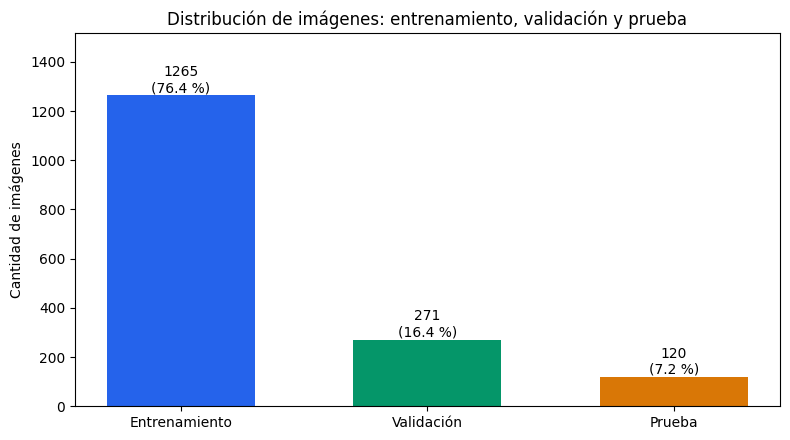

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt

EXTENSIONES_IMAGEN = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
PARTICIONES = (
    ("train", "Entrenamiento"),
    ("valid", "Validación"),
    ("test", "Prueba"),
)


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def contar_imagenes(directorio: Path) -> int:
    if not directorio.is_dir():
        return 0
    return sum(
        1
        for archivo in directorio.iterdir()
        if archivo.is_file() and archivo.suffix.lower() in EXTENSIONES_IMAGEN
    )


directorio_dataset = None
try:
    directorio_dataset = DIRECTORIO_DATASET
except NameError:
    directorio_dataset = raiz_del_repo() / "dataset"

if not directorio_dataset.is_dir():
    raise FileNotFoundError(
        f"No está {directorio_dataset}. Ejecutá antes la celda de descarga."
    )

nombres = []
conteos = []
for carpeta, etiqueta in PARTICIONES:
    cantidad = contar_imagenes(directorio_dataset / carpeta / "images")
    nombres.append(etiqueta)
    conteos.append(cantidad)
    if cantidad == 0:
        print(f"Aviso: no hay imágenes en {carpeta}/images")

total = sum(conteos)
if total == 0:
    raise RuntimeError(f"No se encontraron imágenes en {directorio_dataset}.")

print("Imágenes por partición")
print("---------------------")
for etiqueta, cantidad in zip(nombres, conteos):
    porcentaje = 100 * cantidad / total
    print(f"{etiqueta:15} {cantidad:5d}  ({porcentaje:5.1f} %)")
print(f"{'Total':15} {total:5d}  (100.0 %)")

figura, eje = plt.subplots(figsize=(8, 4.5))
colores = ("#2563eb", "#059669", "#d97706")
barras = eje.bar(nombres, conteos, color=colores, width=0.6)
eje.set_ylabel("Cantidad de imágenes")
eje.set_title("Distribución de imágenes: entrenamiento, validación y prueba")
eje.set_ylim(0, max(conteos) * 1.2)
for barra, cantidad in zip(barras, conteos):
    porcentaje = 100 * cantidad / total
    eje.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{cantidad}\n({porcentaje:.1f} %)",
        ha="center",
        va="bottom",
    )
figura.tight_layout()
plt.show()


Inclinación respecto de la vertical (grados)
Partición             n      p10      p50      p90    media    %>15°    %>45°
Entrenamiento     20354      0.5      3.4     79.8     18.4     23.7     18.6
Validación         4622      0.4      3.7     78.5     18.0     23.7     17.5
Prueba             1747      0.3      3.7     77.7     18.5     27.6     17.6

Solape AABB: máximo IoU con otra caja de la misma imagen
Partición             n      p10      p50      p90    media    IoU≥0.1    IoU≥0.3    IoU≥0.5
Entrenamiento     20354     0.02     0.24     0.60     0.28       75.6       41.5       18.8
Validación         4622     0.02     0.27     0.64     0.31       76.1       46.2       23.3
Prueba             1747     0.04     0.25     0.70     0.32       79.3       45.0       26.1


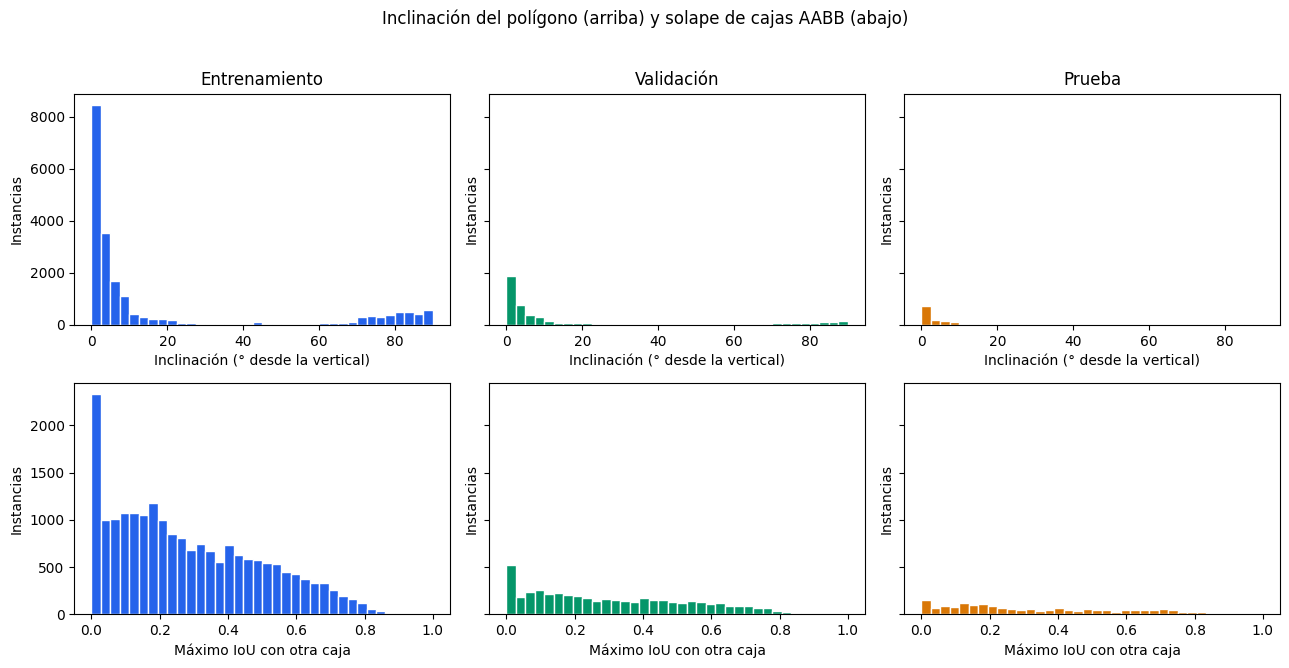

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PARTICIONES = (
    ("train", "Entrenamiento"),
    ("valid", "Validación"),
    ("test", "Prueba"),
)
COLORES = ("#2563eb", "#059669", "#d97706")
UMBRALES_IOU = (0.1, 0.3, 0.5)


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def poligono_desde_linea(linea: str) -> np.ndarray | None:
    partes = linea.split()
    if len(partes) < 7:
        return None
    valores = np.array([float(p) for p in partes[1:]], dtype=float)
    if valores.size % 2 != 0 or valores.size < 6:
        return None
    return valores.reshape(-1, 2)


def caja_xyxy(vertices: np.ndarray) -> tuple[float, float, float, float]:
    xmin, ymin = vertices.min(axis=0)
    xmax, ymax = vertices.max(axis=0)
    return float(xmin), float(ymin), float(xmax), float(ymax)


def inclinacion_grados(vertices: np.ndarray) -> float:
    puntos = vertices - vertices.mean(axis=0)
    if len(puntos) < 2:
        return float("nan")
    cov = np.cov(puntos.T)
    if cov.shape != (2, 2) or np.allclose(cov, 0):
        return float("nan")
    _valores, vectores = np.linalg.eigh(cov)
    eje = vectores[:, int(np.argmax(_valores))]
    norma = float(np.linalg.norm(eje)) + 1e-12
    cos_vertical = abs(float(eje[1])) / norma
    return float(np.degrees(np.arccos(np.clip(cos_vertical, 0.0, 1.0))))


def iou_cajas(a: tuple[float, float, float, float], b: tuple[float, float, float, float]) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = max(ax2 - ax1, 0.0) * max(ay2 - ay1, 0.0)
    area_b = max(bx2 - bx1, 0.0) * max(by2 - by1, 0.0)
    union = area_a + area_b - inter
    return inter / union if union > 1e-12 else 0.0


def metricas_split(directorio_etiquetas: Path) -> dict[str, np.ndarray]:
    inclinaciones: list[float] = []
    max_ious: list[float] = []
    if not directorio_etiquetas.is_dir():
        return {"inclinacion": np.array([]), "max_iou": np.array([])}
    for etiqueta in directorio_etiquetas.glob("*.txt"):
        poligonos: list[np.ndarray] = []
        for linea in etiqueta.read_text(encoding="utf-8").splitlines():
            linea = linea.strip()
            if not linea or linea.startswith("#"):
                continue
            poligono = poligono_desde_linea(linea)
            if poligono is not None:
                poligonos.append(poligono)
        cajas = [caja_xyxy(p) for p in poligonos]
        for poligono in poligonos:
            angulo = inclinacion_grados(poligono)
            if not np.isnan(angulo):
                inclinaciones.append(angulo)
        n = len(cajas)
        for i in range(n):
            mejor = 0.0
            for j in range(n):
                if i == j:
                    continue
                mejor = max(mejor, iou_cajas(cajas[i], cajas[j]))
            max_ious.append(mejor)
    return {
        "inclinacion": np.array(inclinaciones, dtype=float),
        "max_iou": np.array(max_ious, dtype=float),
    }


def percentil(valores: np.ndarray, p: float) -> float:
    if valores.size == 0:
        return float("nan")
    return float(np.percentile(valores, p))


try:
    directorio_dataset = DIRECTORIO_DATASET
except NameError:
    directorio_dataset = raiz_del_repo() / "dataset"

resultados = [
    metricas_split(directorio_dataset / carpeta / "labels") for carpeta, _t in PARTICIONES
]

print("Inclinación respecto de la vertical (grados)")
print(f"{'Partición':16} {'n':>6} {'p10':>8} {'p50':>8} {'p90':>8} {'media':>8} {'%>15°':>8} {'%>45°':>8}")
for (_c, titulo), m in zip(PARTICIONES, resultados):
    ang = m["inclinacion"]
    n = int(ang.size)
    if n == 0:
        print(f"{titulo:16} {0:6d}")
        continue
    print(
        f"{titulo:16} {n:6d} {percentil(ang, 10):8.1f} {percentil(ang, 50):8.1f} "
        f"{percentil(ang, 90):8.1f} {float(ang.mean()):8.1f} "
        f"{100 * np.mean(ang > 15):8.1f} {100 * np.mean(ang > 45):8.1f}"
    )

print("\nSolape AABB: máximo IoU con otra caja de la misma imagen")
encabezado_iou = " ".join(f"{'IoU≥'+str(u):>10}" for u in UMBRALES_IOU)
print(f"{'Partición':16} {'n':>6} {'p10':>8} {'p50':>8} {'p90':>8} {'media':>8} {encabezado_iou}")
for (_c, titulo), m in zip(PARTICIONES, resultados):
    iou = m["max_iou"]
    n = int(iou.size)
    if n == 0:
        print(f"{titulo:16} {0:6d}")
        continue
    pcts = " ".join(f"{100 * np.mean(iou >= u):10.1f}" for u in UMBRALES_IOU)
    print(
        f"{titulo:16} {n:6d} {percentil(iou, 10):8.2f} {percentil(iou, 50):8.2f} "
        f"{percentil(iou, 90):8.2f} {float(iou.mean()):8.2f} {pcts}"
    )

figura, ejes = plt.subplots(2, 3, figsize=(13, 6.5), sharey="row")
for col, ((_c, titulo), m, color) in enumerate(zip(PARTICIONES, resultados, COLORES)):
    ejes[0, col].hist(m["inclinacion"], bins=36, range=(0, 90), color=color, edgecolor="white")
    ejes[0, col].set_title(titulo)
    ejes[0, col].set_xlabel("Inclinación (° desde la vertical)")
    ejes[0, col].set_ylabel("Instancias")

    ejes[1, col].hist(m["max_iou"], bins=36, range=(0, 1), color=color, edgecolor="white")
    ejes[1, col].set_xlabel("Máximo IoU con otra caja")
    ejes[1, col].set_ylabel("Instancias")

figura.suptitle("Inclinación del polígono (arriba) y solape de cajas AABB (abajo)", y=1.02)
figura.tight_layout()
plt.show()


Agrupación por nombre antes de .rf.<hash>
  fuentes distintas:              1218
  fuentes con más de un archivo:  240
  fuentes en más de un split:     104
  archivos sin .rf.hash:          0

Mismo nombre de archivo en dos splits (control)
  train ∩ valid: 0  train ∩ test: 0  valid ∩ test: 0

Cruce de fuentes
Par                     fuentes imgs_izq imgs_der
Entrenamiento ∩ validación       67      107       72
Entrenamiento ∩ prueba       37       67       40
Validación ∩ prueba           8        8        8

Imágenes cuya fuente también está en entrenamiento
Partición             n  cruzadas       %
Validación          271        72   26.6%
Prueba              120        40   33.3%

Copias de la misma fuente dentro de cada split
  Entrenamiento: 1 archivo(s): 798, 2 archivo(s): 78, 3 archivo(s): 49, 4 archivo(s): 22, 5 archivo(s): 5, 6 archivo(s): 3, 7 archivo(s): 2, 8 archivo(s): 1, 11 archivo(s): 1
  Validación: 1 archivo(s): 235, 2 archivo(s): 18
  Prueba: 1 archivo(s): 108, 2 a

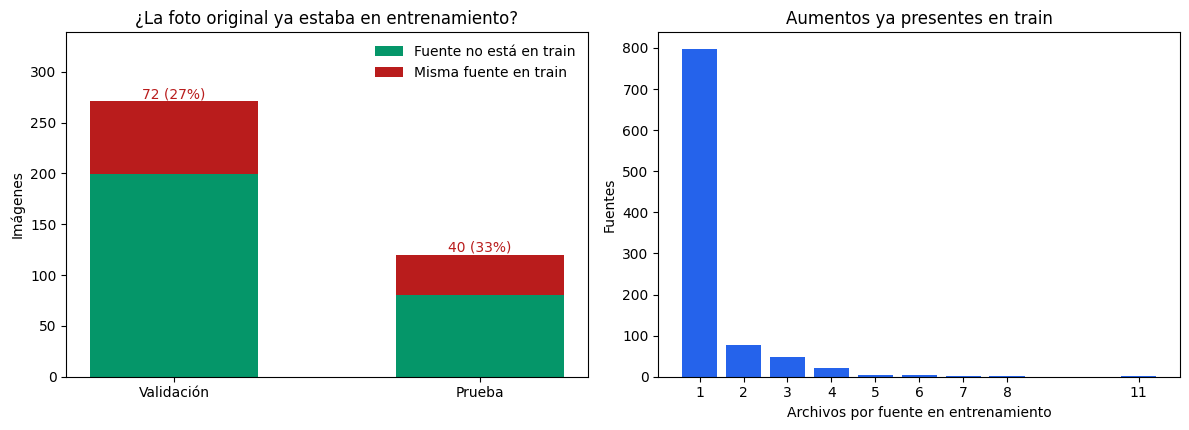

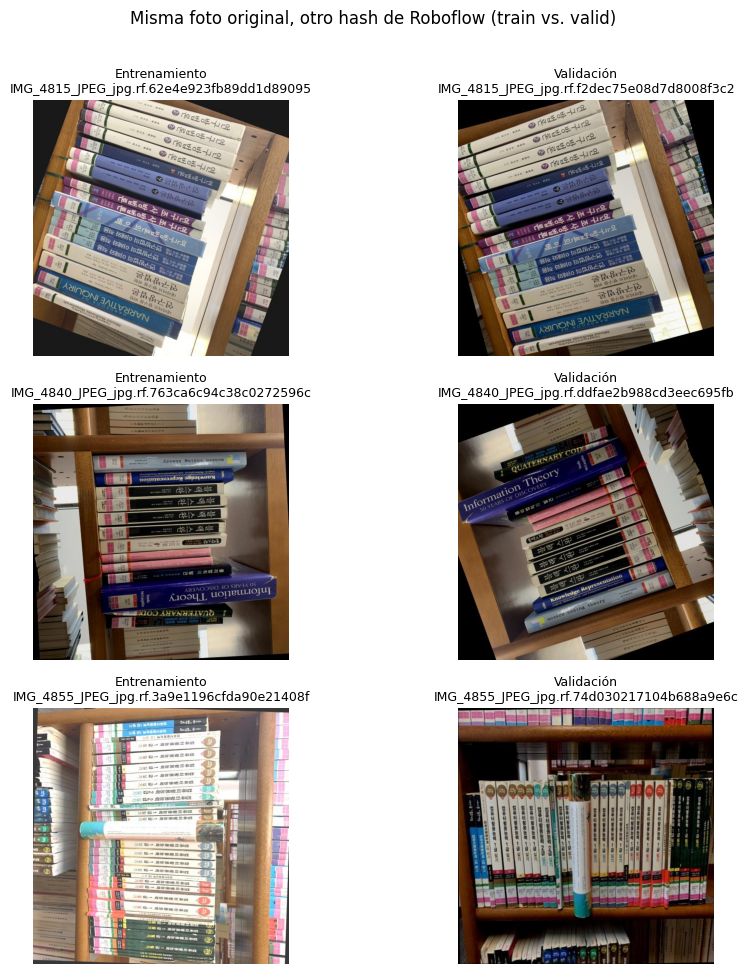

In [7]:
from collections import Counter, defaultdict
from pathlib import Path
import re

import matplotlib.pyplot as plt
from PIL import Image

PARTICIONES = (
    ("train", "Entrenamiento"),
    ("valid", "Validación"),
    ("test", "Prueba"),
)
COLORES = ("#2563eb", "#059669", "#d97706")
EXTENSIONES_IMAGEN = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
PATRON_ROBOFLOW = re.compile(r"^(.*)\.rf\.[0-9a-f]{8,}$", re.IGNORECASE)


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def clave_foto_original(stem: str) -> str:
    coincidencia = PATRON_ROBOFLOW.match(stem)
    if coincidencia:
        return coincidencia.group(1)
    return stem


try:
    directorio_dataset = DIRECTORIO_DATASET
except NameError:
    directorio_dataset = raiz_del_repo() / "dataset"

por_fuente: dict[str, dict[str, list[Path]]] = defaultdict(lambda: defaultdict(list))
sin_hash = 0
nombres_archivo = {carpeta: set() for carpeta, _t in PARTICIONES}
conteo_imagenes = {}

for carpeta, _titulo in PARTICIONES:
    directorio_imagenes = directorio_dataset / carpeta / "images"
    if not directorio_imagenes.is_dir():
        raise FileNotFoundError(
            f"No está {directorio_imagenes}. Ejecutá antes la celda de descarga."
        )
    rutas = [
        ruta
        for ruta in sorted(directorio_imagenes.iterdir())
        if ruta.is_file() and ruta.suffix.lower() in EXTENSIONES_IMAGEN
    ]
    conteo_imagenes[carpeta] = len(rutas)
    for ruta in rutas:
        nombres_archivo[carpeta].add(ruta.name)
        if PATRON_ROBOFLOW.match(ruta.stem) is None:
            sin_hash += 1
        por_fuente[clave_foto_original(ruta.stem)][carpeta].append(ruta)

n_fuentes = len(por_fuente)
n_fuentes_multi_archivo = sum(
    1 for splits in por_fuente.values() if sum(len(v) for v in splits.values()) > 1
)
n_fuentes_multi_split = sum(1 for splits in por_fuente.values() if len(splits) > 1)

print("Agrupación por nombre antes de .rf.<hash>")
print(f"  fuentes distintas:              {n_fuentes}")
print(f"  fuentes con más de un archivo:  {n_fuentes_multi_archivo}")
print(f"  fuentes en más de un split:     {n_fuentes_multi_split}")
print(f"  archivos sin .rf.hash:          {sin_hash}")

print("\nMismo nombre de archivo en dos splits (control)")
print(
    f"  train ∩ valid: {len(nombres_archivo['train'] & nombres_archivo['valid'])}  "
    f"train ∩ test: {len(nombres_archivo['train'] & nombres_archivo['test'])}  "
    f"valid ∩ test: {len(nombres_archivo['valid'] & nombres_archivo['test'])}"
)

print("\nCruce de fuentes")
print(f"{'Par':22} {'fuentes':>8} {'imgs_izq':>8} {'imgs_der':>8}")
pares = (
    ("train", "valid", "Entrenamiento ∩ validación"),
    ("train", "test", "Entrenamiento ∩ prueba"),
    ("valid", "test", "Validación ∩ prueba"),
)
for a, b, etiqueta in pares:
    fuentes_par = [
        splits
        for splits in por_fuente.values()
        if a in splits and b in splits
    ]
    imgs_a = sum(len(s[a]) for s in fuentes_par)
    imgs_b = sum(len(s[b]) for s in fuentes_par)
    print(f"{etiqueta:22} {len(fuentes_par):8d} {imgs_a:8d} {imgs_b:8d}")

print("\nImágenes cuya fuente también está en entrenamiento")
print(f"{'Partición':16} {'n':>6} {'cruzadas':>9} {'%':>7}")
cruzadas_con_train = {}
for carpeta, titulo in PARTICIONES:
    if carpeta == "train":
        continue
    n_cruzadas = sum(
        len(splits[carpeta])
        for splits in por_fuente.values()
        if carpeta in splits and "train" in splits
    )
    n_total = conteo_imagenes[carpeta]
    cruzadas_con_train[carpeta] = n_cruzadas
    pct = 100 * n_cruzadas / n_total if n_total else 0.0
    print(f"{titulo:16} {n_total:6d} {n_cruzadas:9d} {pct:6.1f}%")

print("\nCopias de la misma fuente dentro de cada split")
for carpeta, titulo in PARTICIONES:
    hist = Counter(
        len(splits[carpeta])
        for splits in por_fuente.values()
        if carpeta in splits
    )
    resumen = ", ".join(
        f"{k} archivo(s): {hist[k]}" for k in sorted(hist)
    )
    print(f"  {titulo}: {resumen}")

# --- figuras ---
figura, (eje_cruce, eje_copias) = plt.subplots(1, 2, figsize=(12, 4.4))

etiquetas_bar = ["Validación", "Prueba"]
claves_bar = ["valid", "test"]
n_cruz = [cruzadas_con_train[c] for c in claves_bar]
n_limpias = [conteo_imagenes[c] - cruzadas_con_train[c] for c in claves_bar]
x = range(len(etiquetas_bar))
ancho = 0.55
eje_cruce.bar(x, n_limpias, ancho, label="Fuente no está en train", color="#059669")
eje_cruce.bar(
    x,
    n_cruz,
    ancho,
    bottom=n_limpias,
    label="Misma fuente en train",
    color="#b91c1c",
)
eje_cruce.set_xticks(list(x), etiquetas_bar)
eje_cruce.set_ylabel("Imágenes")
eje_cruce.set_title("¿La foto original ya estaba en entrenamiento?")
eje_cruce.legend(frameon=False)
eje_cruce.set_ylim(0, max(conteo_imagenes[c] for c in claves_bar) * 1.25)
for i, (limpia, cruz, total) in enumerate(
    zip(n_limpias, n_cruz, [conteo_imagenes[c] for c in claves_bar])
):
    if cruz:
        eje_cruce.text(
            i,
            limpia + cruz,
            f"{cruz} ({100 * cruz / total:.0f}%)",
            ha="center",
            va="bottom",
            color="#b91c1c",
        )

hist_train = Counter(
    len(splits["train"]) for splits in por_fuente.values() if "train" in splits
)
ks = sorted(hist_train)
vs = [hist_train[k] for k in ks]
eje_copias.bar(ks, vs, color="#2563eb", width=0.8)
eje_copias.set_xlabel("Archivos por fuente en entrenamiento")
eje_copias.set_ylabel("Fuentes")
eje_copias.set_title("Aumentos ya presentes en train")
eje_copias.set_xticks(ks)
figura.tight_layout()
plt.show()

# --- galería: 3 fuentes en train y valid ---
fuentes_ejemplo = []
for clave, splits in sorted(por_fuente.items()):
    if "train" in splits and "valid" in splits:
        fuentes_ejemplo.append((clave, splits["train"][0], splits["valid"][0]))
    if len(fuentes_ejemplo) == 3:
        break

if fuentes_ejemplo:
    figura_g, ejes = plt.subplots(
        len(fuentes_ejemplo), 2, figsize=(10, 3.2 * len(fuentes_ejemplo))
    )
    if len(fuentes_ejemplo) == 1:
        ejes = [ejes]
    for fila, (clave, ruta_train, ruta_valid) in enumerate(fuentes_ejemplo):
        for eje, ruta, lado in (
            (ejes[fila][0], ruta_train, "Entrenamiento"),
            (ejes[fila][1], ruta_valid, "Validación"),
        ):
            eje.imshow(Image.open(ruta).convert("RGB"))
            eje.set_title(f"{lado}\n{ruta.name[:42]}", fontsize=9)
            eje.axis("off")
        ejes[fila][0].set_ylabel(clave[:28], fontsize=8)
    figura_g.suptitle(
        "Misma foto original, otro hash de Roboflow (train vs. valid)", y=1.01
    )
    figura_g.tight_layout()
    plt.show()
else:
    print("No hay fuentes compartidas entre train y valid: no se arma galería.")


# Segmentación de lomos con Mask R-CNN

## Objetivo

Entrenar **Mask R-CNN con backbone ResNet-50 FPN v2** para identificar y segmentar cada lomo en fotografías de estanterías. La máscara de cada instancia permitirá obtener recortes más precisos para la posterior etapa de OCR.

## Dataset

Se utiliza **Book Spine 2, versión 4**, con las particiones originales: 1.265 imágenes de entrenamiento, 271 de validación y 120 de prueba. Las etiquetas están en formato YOLO de segmentación: cada lomo se describe mediante un polígono con coordenadas normalizadas.

El `Dataset` convierte cada polígono en una máscara binaria y calcula su caja envolvente. Para Torchvision se usan dos clases: `0` para fondo y `1` para lomo. Las imágenes sin lomos se conservan con objetivos vacíos.

## Modelo

Se parte de pesos preentrenados en COCO y se reemplazan las cabezas de clasificación de cajas y de predicción de máscaras para adaptarlas a la única clase del problema. La entrada se procesa a 640 × 640 píxeles.

La salida incluye, para cada lomo detectado, una caja, una confianza y una máscara. A diferencia de una caja rectangular, la máscara permite separar mejor el lomo de sus vecinos, algo especialmente importante en estanterías densas y para evitar que el OCR lea texto de otro libro.

In [8]:
from pathlib import Path

import cv2
import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader


def encontrar_dataset() -> Path:
    for base in (Path.cwd(), Path.cwd().parent):
        ruta = base / "dataset"
        if (ruta / "data.yaml").is_file():
            return ruta
    raise FileNotFoundError("No encontré dataset/data.yaml")


class BookSpineMasks(Dataset):
    EXTENSIONES = {".jpg", ".jpeg", ".png", ".webp"}

    def __init__(self, raiz: Path, split: str):
        self.imagenes_dir = raiz / split / "images"
        self.labels_dir = raiz / split / "labels"

        self.imagenes = sorted(
            p for p in self.imagenes_dir.iterdir()
            if p.suffix.lower() in self.EXTENSIONES
        )

        if not self.imagenes:
            raise ValueError(f"No encontré imágenes en {self.imagenes_dir}")

    def __len__(self):
        return len(self.imagenes)

    def __getitem__(self, indice):
        ruta_imagen = self.imagenes[indice]
        imagen = np.asarray(
            Image.open(ruta_imagen).convert("RGB"),
            dtype=np.uint8,
        ).copy()

        alto, ancho = imagen.shape[:2]
        ruta_label = self.labels_dir / f"{ruta_imagen.stem}.txt"

        cajas = []
        mascaras = []

        if ruta_label.is_file():
            for linea in ruta_label.read_text(encoding="utf-8").splitlines():
                partes = linea.split()

                # Formato YOLO-seg: clase x1 y1 x2 y2 ... (normalizados)
                if len(partes) < 7 or (len(partes) - 1) % 2:
                    continue

                puntos = np.asarray(
                    [float(valor) for valor in partes[1:]],
                    dtype=np.float32,
                ).reshape(-1, 2)

                puntos[:, 0] = np.clip(puntos[:, 0] * (ancho - 1), 0, ancho - 1)
                puntos[:, 1] = np.clip(puntos[:, 1] * (alto - 1), 0, alto - 1)
                puntos = np.rint(puntos).astype(np.int32)

                mascara = np.zeros((alto, ancho), dtype=np.uint8)
                cv2.fillPoly(mascara, [puntos], color=1)

                ys, xs = np.where(mascara > 0)
                if len(xs) == 0:
                    continue

                cajas.append([
                    float(xs.min()),
                    float(ys.min()),
                    float(xs.max() + 1),
                    float(ys.max() + 1),
                ])
                mascaras.append(mascara)

        if mascaras:
            mascaras = torch.as_tensor(np.stack(mascaras), dtype=torch.uint8)
            cajas = torch.as_tensor(cajas, dtype=torch.float32)
        else:
            # Hay imágenes sin lomos; también deben poder pasar por el modelo.
            mascaras = torch.zeros((0, alto, ancho), dtype=torch.uint8)
            cajas = torch.zeros((0, 4), dtype=torch.float32)

        cantidad = len(cajas)
        objetivo = {
            "boxes": cajas,
            "labels": torch.ones(cantidad, dtype=torch.int64),
            "masks": mascaras,
            "image_id": torch.tensor(indice),
            "area": mascaras.sum(dim=(1, 2)).to(torch.float32),
            "iscrowd": torch.zeros(cantidad, dtype=torch.int64),
        }

        # Torchvision espera imagen CHW, float32 y valores entre 0 y 1.
        imagen = torch.from_numpy(imagen).permute(2, 0, 1).float() / 255.0
        return imagen, objetivo


def agrupar_lote(elementos):
    imagenes, objetivos = zip(*elementos)
    return list(imagenes), list(objetivos)


RAIZ_DATASET = encontrar_dataset()

train_ds = BookSpineMasks(RAIZ_DATASET, "train")
valid_ds = BookSpineMasks(RAIZ_DATASET, "valid")

train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,  # compatible con Windows y notebooks
    collate_fn=agrupar_lote,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=agrupar_lote,
)

imagen, objetivo = train_ds[0]
print("Imágenes:", len(train_ds), len(valid_ds))
print("Imagen:", tuple(imagen.shape))
print("Cajas:", tuple(objetivo["boxes"].shape))
print("Máscaras:", tuple(objetivo["masks"].shape))

Imágenes: 1265 271
Imagen: (3, 640, 640)
Cajas: (4, 4)
Máscaras: (4, 640, 640)


## Entrenamiento

En cada lote, Mask R-CNN calcula pérdidas para la generación de propuestas, la clasificación y ajuste de cajas, y la predicción de máscaras. Se suman estas pérdidas y se actualizan los pesos mediante retropropagación.

Se utiliza un lote de **2 imágenes**. Cuando hay GPU CUDA disponible, el entrenamiento emplea precisión mixta para reducir el consumo de memoria. Si alguna pérdida deja de ser finita, la ejecución se detiene para evitar guardar pesos inválidos.

In [9]:
import torchvision

from torchvision.models.detection import (
    MaskRCNN_ResNet50_FPN_V2_Weights,
    maskrcnn_resnet50_fpn_v2,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


def crear_modelo():
    modelo = maskrcnn_resnet50_fpn_v2(
        weights=MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT,
        min_size=640,
        max_size=640,
        box_detections_per_img=100,
        box_nms_thresh=0.7,
    )

    # Dos clases: 0 = fondo, 1 = lomo.
    entradas_caja = modelo.roi_heads.box_predictor.cls_score.in_features
    modelo.roi_heads.box_predictor = FastRCNNPredictor(
        entradas_caja,
        num_classes=2,
    )

    entradas_mascara = modelo.roi_heads.mask_predictor.conv5_mask.in_channels
    modelo.roi_heads.mask_predictor = MaskRCNNPredictor(
        entradas_mascara,
        dim_reduced=256,
        num_classes=2,
    )

    return modelo


dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = crear_modelo().to(dispositivo)

print("Dispositivo:", dispositivo)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


100%|██████████| 177M/177M [00:01<00:00, 146MB/s]


Dispositivo: cuda


In [10]:
from contextlib import nullcontext

from tqdm.auto import tqdm


def entrenar_epoca(modelo, loader, optimizador, scaler, dispositivo):
    modelo.train()
    perdida_acumulada = 0.0
    usar_amp = dispositivo.type == "cuda"

    for imagenes, objetivos in tqdm(loader, desc="Entrenamiento"):
        imagenes = [imagen.to(dispositivo) for imagen in imagenes]
        objetivos = [
            {clave: valor.to(dispositivo) for clave, valor in objetivo.items()}
            for objetivo in objetivos
        ]

        optimizador.zero_grad(set_to_none=True)

        contexto_amp = (
            torch.autocast(device_type="cuda", dtype=torch.float16)
            if usar_amp else nullcontext()
        )

        with contexto_amp:
            perdidas = modelo(imagenes, objetivos)
            perdida = sum(perdidas.values())

        if not torch.isfinite(perdida):
            raise RuntimeError(f"Pérdida no finita: {perdidas}")

        scaler.scale(perdida).backward()
        scaler.step(optimizador)
        scaler.update()

        perdida_acumulada += perdida.detach().item()

    return perdida_acumulada / len(loader)

In [13]:
%pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.4 MB/s eta 0:00:00


## Evaluación en validación

Después de cada época, el modelo se evalúa sobre las **271 imágenes de validación**. Se calculan por separado:

- **mAP@0.5 de máscaras** y **mAP@0.5:0.95 de máscaras**.
- **mAP@0.5 de cajas** y **mAP@0.5:0.95 de cajas**.

Solo se consideran predicciones con confianza **≥ 0,5**. Las máscaras predichas, que inicialmente contienen probabilidades por píxel, se convierten en máscaras binarias con umbral **0,5**.

La métrica principal para seleccionar el modelo es el **mAP@0.5 de máscaras**, porque el propósito de esta arquitectura es obtener un recorte individual y preciso de cada lomo.

In [14]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision


SCORE_EVAL = 0.5
UMBRAL_MASCARA = 0.5


@torch.inference_mode()
def evaluar(modelo, loader, dispositivo):
    modelo.eval()

    metrica = MeanAveragePrecision(
        box_format="xyxy",
        iou_type=("bbox", "segm"),
        max_detection_thresholds=[1, 10, 100],
    )

    for imagenes, objetivos in tqdm(loader, desc="Validación"):
        imagenes_gpu = [imagen.to(dispositivo) for imagen in imagenes]
        salidas = modelo(imagenes_gpu)

        predicciones = []
        referencias = []

        for salida, objetivo in zip(salidas, objetivos):
            conservar = salida["scores"] >= SCORE_EVAL

            predicciones.append({
                "boxes": salida["boxes"][conservar].cpu(),
                "scores": salida["scores"][conservar].cpu(),
                "labels": salida["labels"][conservar].cpu(),
                "masks": (
                    salida["masks"][conservar, 0] >= UMBRAL_MASCARA
                ).cpu(),
            })

            referencias.append({
                "boxes": objetivo["boxes"],
                "labels": objetivo["labels"],
                "masks": objetivo["masks"].bool(),
                "area": objetivo["area"],
                "iscrowd": objetivo["iscrowd"],
            })

        metrica.update(predicciones, referencias)

    resultado = metrica.compute()

    return {
        "mask_map50": resultado["segm_map_50"].item(),
        "mask_map50_95": resultado["segm_map"].item(),
        "box_map50": resultado["bbox_map_50"].item(),
        "box_map50_95": resultado["bbox_map"].item(),
    }

## Configuración de la corrida y selección del modelo

Se fija la semilla en **42** y se entrena durante **20 épocas** con el optimizador SGD: tasa de aprendizaje inicial `0,005`, momentum `0,9` y decaimiento de pesos `0,0005`. La tasa de aprendizaje disminuye después de las épocas 12 y 18.

Al finalizar cada época se registran la pérdida de entrenamiento y las métricas de validación. Si mejora el **mAP@0.5 de máscaras**, se guarda un checkpoint en:

`results/checkpoints/mask_rcnn/mejor_mask_map50.pt`

El checkpoint incluye los pesos, la época y la configuración principal. La partición de **prueba (`test`) no interviene en el entrenamiento ni en la selección**: se reserva para una evaluación final del modelo elegido.

In [15]:
import random


SEMILLA = 42
EPOCAS = 30

random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMILLA)

# Recreamos el modelo después de fijar la semilla.
modelo = crear_modelo().to(dispositivo)

optimizador = torch.optim.SGD(
    modelo.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005,
)

planificador = torch.optim.lr_scheduler.MultiStepLR(
    optimizador,
    milestones=[12, 18],
    gamma=0.1,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(dispositivo.type == "cuda"),
)

ruta_checkpoint = (
    RAIZ_DATASET.parent
    / "results"
    / "checkpoints"
    / "mask_rcnn"
    / "mejor_mask_map50.pt"
)
ruta_checkpoint.parent.mkdir(parents=True, exist_ok=True)

ruta_pesos_mejor = (
    RAIZ_DATASET.parent
    / "pesos"
    / "mask_rcnn"
    / "mejor_mask_map50.pt"
)
ruta_pesos_mejor.parent.mkdir(parents=True, exist_ok=True)

mejor_map50 = -1.0
historial = []

for epoca in range(1, EPOCAS + 1):
    perdida_train = entrenar_epoca(
        modelo, train_loader, optimizador, scaler, dispositivo
    )
    metricas_val = evaluar(modelo, valid_loader, dispositivo)

    fila = {
        "epoca": epoca,
        "loss_train": perdida_train,
        **metricas_val,
    }
    historial.append(fila)

    print(
        f"Época {epoca:02d}/{EPOCAS} | "
        f"loss={perdida_train:.4f} | "
        f"mask mAP50={metricas_val['mask_map50']:.4f} | "
        f"mask mAP50:95={metricas_val['mask_map50_95']:.4f} | "
        f"box mAP50={metricas_val['box_map50']:.4f}"
    )

    if metricas_val["mask_map50"] > mejor_map50:
        mejor_map50 = metricas_val["mask_map50"]

        estado_ckpt = {
            "epoca": epoca,
            "modelo": modelo.state_dict(),
            "optimizador": optimizador.state_dict(),
            "mask_map50_valid": mejor_map50,
            "configuracion": {
                "modelo": "maskrcnn_resnet50_fpn_v2",
                "semilla": SEMILLA,
                "epocas": EPOCAS,
                "batch_size": 2,
                "score_eval": SCORE_EVAL,
                "umbral_mascara": UMBRAL_MASCARA,
            },
        }
        torch.save(estado_ckpt, ruta_checkpoint)
        torch.save(estado_ckpt, ruta_pesos_mejor)

        print(f"  Nuevo mejor checkpoint: {ruta_checkpoint}")
        print(f"  Pesos (mejor) → {ruta_pesos_mejor}")

    planificador.step()

print(f"Mejor mAP@0.5 de máscara: {mejor_map50:.4f}")

Entrenamiento:   0%|          | 0/633 [00:00<?, ?it/s]

Validación:   0%|          | 0/271 [00:00<?, ?it/s]

Época 01/20 | loss=0.9773 | mask mAP50=0.7076 | mask mAP50:95=0.4399 | box mAP50=0.8908
  Nuevo mejor checkpoint: /content/results/checkpoints/mask_rcnn/mejor_mask_map50.pt


Entrenamiento:   0%|          | 0/633 [00:00<?, ?it/s]

Validación:   0%|          | 0/271 [00:00<?, ?it/s]

...

Validación:   0%|          | 0/271 [00:00<?, ?it/s]

Época 19/20 | loss=0.2982 | mask mAP50=0.7769 | mask mAP50:95=0.5022 | box mAP50=0.9145


Entrenamiento:   0%|          | 0/633 [00:00<?, ?it/s]

Validación:   0%|          | 0/271 [00:00<?, ?it/s]

Época 20/20 | loss=0.2973 | mask mAP50=0.7768 | mask mAP50:95=0.5042 | box mAP50=0.9156
Mejor mAP@0.5 de máscara: 0.7846


## Resultado del entrenamiento

Se completaron las 20 épocas previstas. El mejor checkpoint se obtuvo en la **época 12**, con los siguientes resultados de validación:

| Métrica | Resultado |
| :--- | ---: |
| Pérdida de entrenamiento | 0,3783 |
| mAP@0.5 de máscara | 0,7846 |
| mAP@0.5:0.95 de máscara | 0,5074 |
| mAP@0.5 de caja | 0,9089 |

Después de la época 12, la pérdida de entrenamiento continuó disminuyendo hasta 0,2973, pero el mAP@0.5 de máscara no volvió a superar el valor seleccionado. Esto justifica conservar el checkpoint de la época 12 en lugar de utilizar directamente los pesos de la última época.

A continuación se carga ese checkpoint y se realiza la evaluación detallada sobre validación, casos densos, lomos inclinados y, finalmente, la partición de prueba.

In [16]:
import json
import random
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from matplotlib.patches import Rectangle
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import box_iou
from tqdm.auto import tqdm


SCORE_EVAL = 0.50
IOU_EVAL = 0.50
UMBRAL_MASCARA = 0.50
IOU_DENSO = 0.50
ANGULO_INCLINADO = 45.0

RUTA_MEJOR = (
    RAIZ_DATASET.parent
    / "results/checkpoints/mask_rcnn/mejor_mask_map50.pt"
)
DIRECTORIO_TABLAS = RAIZ_DATASET.parent / "results/tables"
DIRECTORIO_FIGURAS = RAIZ_DATASET.parent / "results/figures/mask_rcnn"

DIRECTORIO_TABLAS.mkdir(parents=True, exist_ok=True)
DIRECTORIO_FIGURAS.mkdir(parents=True, exist_ok=True)

if not RUTA_MEJOR.is_file():
    raise FileNotFoundError(f"No existe el checkpoint: {RUTA_MEJOR}")

checkpoint = torch.load(
    RUTA_MEJOR,
    map_location="cpu",
    weights_only=True,
)

# 'modelo' y 'dispositivo' vienen de las celdas anteriores.
modelo.load_state_dict(checkpoint["modelo"])
modelo = modelo.to(dispositivo).eval()

test_ds = BookSpineMasks(RAIZ_DATASET, "test")

print("Checkpoint:", RUTA_MEJOR)
print("Mejor época:", checkpoint["epoca"])
print("mAP@0.5 de máscara guardado:", checkpoint["mask_map50_valid"])
print("Validación:", len(valid_ds), "imágenes")
print("Test:", len(test_ds), "imágenes")
print(
    "Hardware:",
    torch.cuda.get_device_name(0)
    if dispositivo.type == "cuda" else "CPU",
)

Checkpoint: /content/results/checkpoints/mask_rcnn/mejor_mask_map50.pt
Mejor época: 12
mAP@0.5 de máscara guardado: 0.7845774292945862
Validación: 271 imágenes
Test: 120 imágenes
Hardware: Tesla T4


In [17]:
def geometria_imagen(dataset, indice, target):
    """Densidad de la imagen e índices de GT inclinados."""
    ruta = dataset.labels_dir / f"{dataset.imagenes[indice].stem}.txt"
    alto, ancho = target["masks"].shape[-2:]

    cajas_norm = []
    angulos = []

    if ruta.is_file():
        for linea in ruta.read_text(encoding="utf-8").splitlines():
            partes = linea.split()
            if len(partes) < 7 or (len(partes) - 1) % 2:
                continue

            vertices = np.asarray(
                [float(v) for v in partes[1:]],
                dtype=np.float32,
            ).reshape(-1, 2)

            pixeles = vertices.copy()
            pixeles[:, 0] = np.clip(
                pixeles[:, 0] * (ancho - 1), 0, ancho - 1
            )
            pixeles[:, 1] = np.clip(
                pixeles[:, 1] * (alto - 1), 0, alto - 1
            )
            pixeles = np.rint(pixeles).astype(np.int32)

            mascara = np.zeros((alto, ancho), dtype=np.uint8)
            cv2.fillPoly(mascara, [pixeles], color=1)
            if not mascara.any():
                continue  # mismo descarte que en BookSpineMasks

            minimo = vertices.min(axis=0)
            maximo = vertices.max(axis=0)
            cajas_norm.append([
                minimo[0], minimo[1], maximo[0], maximo[1]
            ])

            centrados = vertices - vertices.mean(axis=0)
            covarianza = np.cov(centrados.T)
            if np.allclose(covarianza, 0):
                angulos.append(float("nan"))
            else:
                valores, vectores = np.linalg.eigh(covarianza)
                eje = vectores[:, np.argmax(valores)]
                cos_vertical = abs(eje[1]) / max(np.linalg.norm(eje), 1e-12)
                angulos.append(
                    float(np.degrees(np.arccos(np.clip(cos_vertical, 0, 1))))
                )

    if len(angulos) != len(target["labels"]):
        raise ValueError(
            f"Las etiquetas de {dataset.imagenes[indice].name} "
            "no coinciden con las máscaras del Dataset."
        )

    densa = False
    if len(cajas_norm) >= 2:
        cajas = torch.tensor(cajas_norm, dtype=torch.float32)
        solapes = box_iou(cajas, cajas)
        solapes.fill_diagonal_(0)
        densa = bool((solapes >= IOU_DENSO).any())

    inclinados = [
        i for i, angulo in enumerate(angulos)
        if np.isfinite(angulo) and angulo > ANGULO_INCLINADO
    ]
    return densa, inclinados


def iou_mascaras(pred, gt):
    """Matriz de IoU entre máscaras binarias."""
    n_pred, n_gt = pred.shape[0], gt.shape[0]
    if n_pred == 0 or n_gt == 0:
        return torch.zeros((n_pred, n_gt), device=pred.device)

    a = pred.flatten(1).float()
    b = gt.flatten(1).float()
    interseccion = a @ b.T
    union = a.sum(1)[:, None] + b.sum(1)[None, :] - interseccion
    return interseccion / union.clamp_min(1)


def contar_tp_fp_fn(scores, ious):
    """Matching guloso por score, como en los notebooks existentes."""
    n_pred, n_gt = ious.shape

    if n_pred == 0:
        return 0, 0, n_gt
    if n_gt == 0:
        return 0, n_pred, 0

    usados = torch.zeros(n_gt, dtype=torch.bool, device=ious.device)
    tp = 0

    for indice in scores.argsort(descending=True).tolist():
        mejor_iou, j = ious[indice].max(dim=0)
        if mejor_iou >= IOU_EVAL and not usados[j]:
            usados[j] = True
            tp += 1

    return tp, n_pred - tp, int((~usados).sum().item())


def nuevo_estado():
    return {
        "metrica": MeanAveragePrecision(
            box_format="xyxy",
            iou_type=("bbox", "segm"),
            max_detection_thresholds=[1, 10, 100],
        ),
        "imagenes": 0,
        "gt": 0,
        "caja": [0, 0, 0],     # TP, FP, FN
        "mascara": [0, 0, 0],
    }


def actualizar_estado(estado, pred, gt):
    """Agrega una imagen a mAP y P/R. pred y gt están en el dispositivo."""
    estado["metrica"].update(
        [{
            "boxes": pred["boxes"].cpu(),
            "scores": pred["scores"].cpu(),
            "labels": pred["labels"].cpu(),
            "masks": pred["masks"].cpu(),
        }],
        [{
            "boxes": gt["boxes"].cpu(),
            "labels": gt["labels"].cpu(),
            "masks": gt["masks"].cpu(),
            "area": gt["area"].cpu(),
            "iscrowd": gt["iscrowd"].cpu(),
        }],
    )

    ious_caja = box_iou(pred["boxes"], gt["boxes"])
    ious_mascara = iou_mascaras(pred["masks"], gt["masks"])

    conteo_caja = contar_tp_fp_fn(pred["scores"], ious_caja)
    conteo_mascara = contar_tp_fp_fn(pred["scores"], ious_mascara)

    estado["caja"] = [
        a + b for a, b in zip(estado["caja"], conteo_caja)
    ]
    estado["mascara"] = [
        a + b for a, b in zip(estado["mascara"], conteo_mascara)
    ]
    estado["imagenes"] += 1
    estado["gt"] += len(gt["labels"])

    return conteo_caja, conteo_mascara


def resumir_estado(estado):
    mapa = estado["metrica"].compute()
    tp_c, fp_c, fn_c = estado["caja"]
    tp_m, fp_m, fn_m = estado["mascara"]

    return {
        "imagenes": estado["imagenes"],
        "gt": estado["gt"],
        "mask_map50": float(mapa["segm_map_50"]),
        "mask_map50_95": float(mapa["segm_map"]),
        "mask_precision": tp_m / (tp_m + fp_m) if tp_m + fp_m else 0.0,
        "mask_recall": tp_m / (tp_m + fn_m) if tp_m + fn_m else 0.0,
        "box_map50": float(mapa["bbox_map_50"]),
        "box_map50_95": float(mapa["bbox_map"]),
        "box_precision": tp_c / (tp_c + fp_c) if tp_c + fp_c else 0.0,
        "box_recall": tp_c / (tp_c + fn_c) if tp_c + fn_c else 0.0,
    }


@torch.inference_mode()
def evaluar_particion(dataset, incluir_subconjuntos=False):
    modelo.eval()

    estados = {"global": nuevo_estado()}
    if incluir_subconjuntos:
        estados["denso"] = nuevo_estado()
        estados["inclinado"] = nuevo_estado()

    detalle = []

    for indice in tqdm(range(len(dataset)), desc="Evaluación"):
        imagen, objetivo = dataset[indice]
        salida = modelo([imagen.to(dispositivo)])[0]

        conservar = (
            (salida["scores"] >= SCORE_EVAL)
            & (salida["labels"] == 1)
        )
        pred = {
            "boxes": salida["boxes"][conservar],
            "scores": salida["scores"][conservar],
            "labels": salida["labels"][conservar],
            "masks": (
                salida["masks"][conservar, 0] >= UMBRAL_MASCARA
            ),
        }
        gt = {
            clave: objetivo[clave].to(dispositivo)
            for clave in ("boxes", "labels", "masks", "area", "iscrowd")
        }
        gt["masks"] = gt["masks"].bool()

        _, conteo_mascara = actualizar_estado(estados["global"], pred, gt)

        densa = False
        indices_inclinados = []
        if incluir_subconjuntos:
            densa, indices_inclinados = geometria_imagen(
                dataset, indice, objetivo
            )

            if densa:
                actualizar_estado(estados["denso"], pred, gt)

            if indices_inclinados:
                indices_verticales = [
                    i for i in range(len(gt["labels"]))
                    if i not in indices_inclinados
                ]

                # Igual que en YOLO26s-seg: no penalizar predicciones
                # que corresponden a un GT vertical.
                conservar_pred = torch.ones(
                    len(pred["scores"]),
                    dtype=torch.bool,
                    device=dispositivo,
                )
                if indices_verticales and len(pred["scores"]):
                    solape_vertical = box_iou(
                        pred["boxes"],
                        gt["boxes"][indices_verticales],
                    )
                    conservar_pred = (
                        solape_vertical.max(dim=1).values < IOU_EVAL
                    )

                pred_inc = {
                    clave: valor[conservar_pred]
                    for clave, valor in pred.items()
                }
                gt_inc = {
                    clave: valor[indices_inclinados]
                    for clave, valor in gt.items()
                }
                actualizar_estado(
                    estados["inclinado"], pred_inc, gt_inc
                )

        detalle.append({
            "indice": indice,
            "archivo": dataset.imagenes[indice].name,
            "gt": len(gt["labels"]),
            "tp_mascara": conteo_mascara[0],
            "fp_mascara": conteo_mascara[1],
            "fn_mascara": conteo_mascara[2],
            "densa": densa,
            "inclinada": bool(indices_inclinados),
        })

    resumen = {
        nombre: resumir_estado(estado)
        for nombre, estado in estados.items()
    }
    return resumen, pd.DataFrame(detalle)

Evaluación:   0%|          | 0/271 [00:00<?, ?it/s]

Latencia:   0%|          | 0/55 [00:00<?, ?it/s]

,subconjunto,imagenes,gt,mask_map50,mask_map50_95,mask_precision,mask_recall,box_map50,box_map50_95,box_precision,box_recall,latencia_ms,fps
0,global,271,4622,0.7846,0.5074,0.7846,0.8336,0.9089,0.7282,0.8644,0.9184,117.3399,8.5223
1,denso,121,2296,0.6480,0.3413,0.6610,0.7278,0.8918,0.6870,0.8137,0.8959,NaN,NaN
2,inclinado,72,808,0.6470,0.3350,0.6569,0.7463,0.8753,0.6483,0.7876,0.8948,NaN,NaN


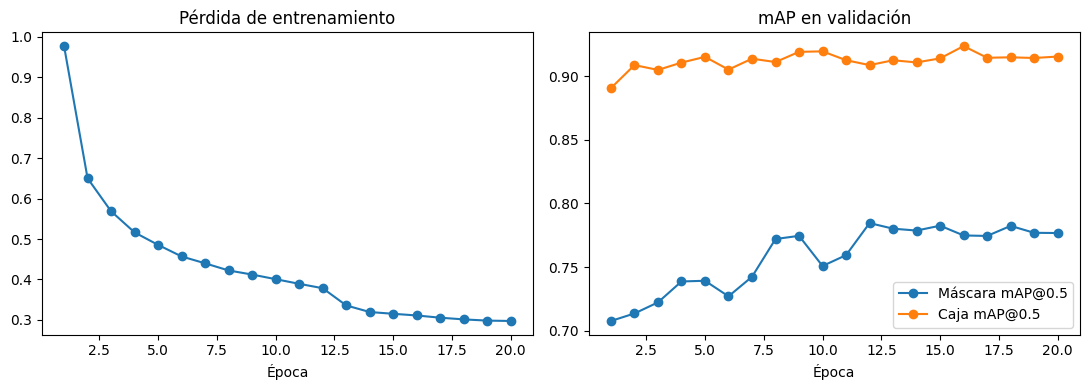

In [18]:
@torch.inference_mode()
def medir_latencia(dataset, warmup=5, mediciones=50):
    modelo.eval()
    tiempos = []

    for indice in tqdm(
        range(min(len(dataset), warmup + mediciones)),
        desc="Latencia",
    ):
        imagen, _ = dataset[indice]
        entrada = [imagen.to(dispositivo)]

        if dispositivo.type == "cuda":
            torch.cuda.synchronize()
        inicio = time.perf_counter()

        _ = modelo(entrada)

        if dispositivo.type == "cuda":
            torch.cuda.synchronize()
        ms = (time.perf_counter() - inicio) * 1000

        if indice >= warmup:
            tiempos.append(ms)

    return float(np.mean(tiempos))


resumen_validacion, detalle_validacion = evaluar_particion(
    valid_ds,
    incluir_subconjuntos=True,
)

latencia_validacion = medir_latencia(valid_ds)
resumen_validacion["global"]["latencia_ms"] = latencia_validacion
resumen_validacion["global"]["fps"] = 1000 / latencia_validacion

tabla_validacion = pd.DataFrame([
    {"subconjunto": nombre, **metricas}
    for nombre, metricas in resumen_validacion.items()
])

display(tabla_validacion.round(4))

tabla_validacion.to_csv(
    DIRECTORIO_TABLAS / "mask_rcnn_subconjuntos_validacion.csv",
    index=False,
)
detalle_validacion.to_csv(
    DIRECTORIO_TABLAS / "mask_rcnn_detalle_validacion.csv",
    index=False,
)

(DIRECTORIO_TABLAS / "mask_rcnn_resumen_validacion.json").write_text(
    json.dumps({
        "checkpoint": str(RUTA_MEJOR),
        "epoca": int(checkpoint["epoca"]),
        "hardware": (
            torch.cuda.get_device_name(0)
            if dispositivo.type == "cuda" else "CPU"
        ),
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "score_eval": SCORE_EVAL,
        "iou_eval": IOU_EVAL,
        "umbral_mascara": UMBRAL_MASCARA,
        "resultados": resumen_validacion,
    }, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

# El historial existe si seguís en la misma sesión del entrenamiento.
if "historial" in globals() and historial:
    df_historial = pd.DataFrame(historial)
    df_historial.to_csv(
        DIRECTORIO_TABLAS / "mask_rcnn_historial.csv",
        index=False,
    )

    figura, ejes = plt.subplots(1, 2, figsize=(11, 4))
    ejes[0].plot(
        df_historial["epoca"],
        df_historial["loss_train"],
        marker="o",
    )
    ejes[0].set_title("Pérdida de entrenamiento")
    ejes[0].set_xlabel("Época")

    ejes[1].plot(
        df_historial["epoca"],
        df_historial["mask_map50"],
        marker="o",
        label="Máscara mAP@0.5",
    )
    ejes[1].plot(
        df_historial["epoca"],
        df_historial["box_map50"],
        marker="o",
        label="Caja mAP@0.5",
    )
    ejes[1].set_title("mAP en validación")
    ejes[1].set_xlabel("Época")
    ejes[1].legend()

    figura.tight_layout()
    figura.savefig(
        DIRECTORIO_FIGURAS / "curvas_entrenamiento.png",
        dpi=150,
    )
    plt.show()

## Resultados en validación

| Subconjunto | Imágenes | Lomos reales | mAP@0.5 máscara | mAP@0.5:0.95 máscara | Precisión | Recall |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| Validación completa | 271 | 4.622 | 0,7846 | 0,5074 | 0,7846 | 0,8336 |
| Imágenes densas | 121 | 2.296 | 0,6480 | 0,3413 | 0,6610 | 0,7278 |
| Lomos inclinados | 72 | 808 | 0,6470 | 0,3350 | 0,6569 | 0,7463 |

En validación completa, Mask R-CNN obtuvo un **mAP@0.5 de máscara de 0,7846**. El recall de 0,8336 indica que recupera una proporción alta de los lomos anotados, aunque la precisión de 0,7846 muestra que todavía produce falsos positivos.

El rendimiento disminuye en imágenes densas y en lomos inclinados. En ambos subconjuntos, el mAP@0.5 se mantiene alrededor de 0,65, pero el mAP@0.5:0.95 cae hasta aproximadamente 0,34. Esto muestra que el modelo suele localizar los lomos difíciles, aunque las máscaras no siempre coinciden con precisión con sus contornos.

Para cajas, el modelo alcanzó un mAP@0.5 de 0,9089 y un mAP@0.5:0.95 de 0,7282. La diferencia entre las métricas de caja y máscara indica que localizar el lomo resulta más sencillo que reproducir con precisión su forma.

La latencia media fue de 117,34 ms por imagen, equivalente a aproximadamente 8,52 imágenes por segundo, utilizando una GPU Tesla T4 de Google Collab y batch de una imagen.

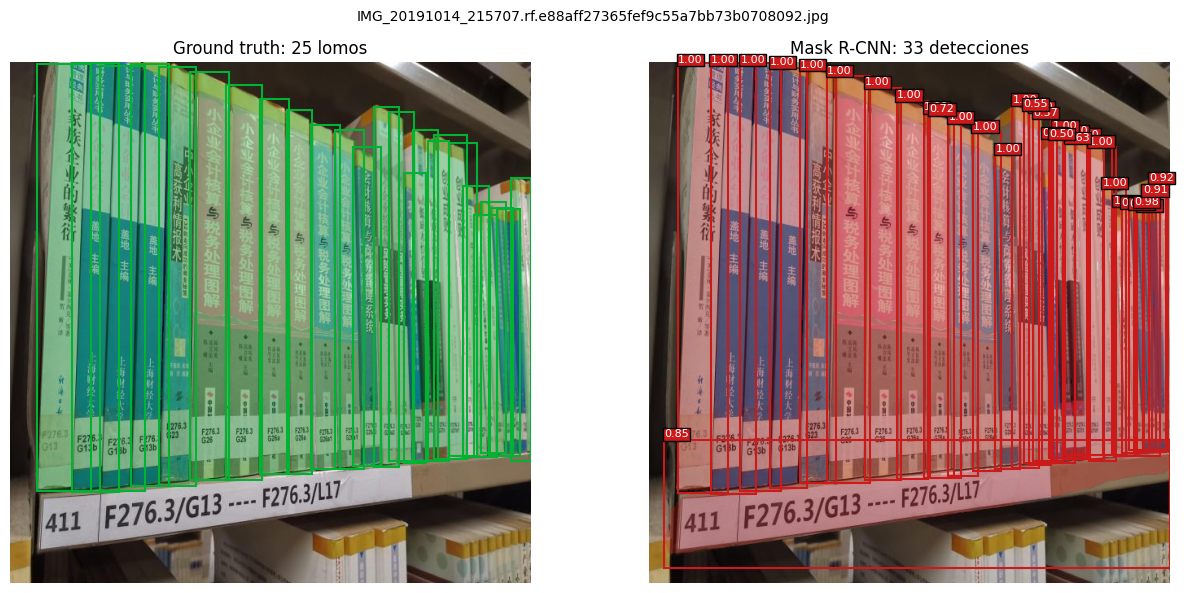

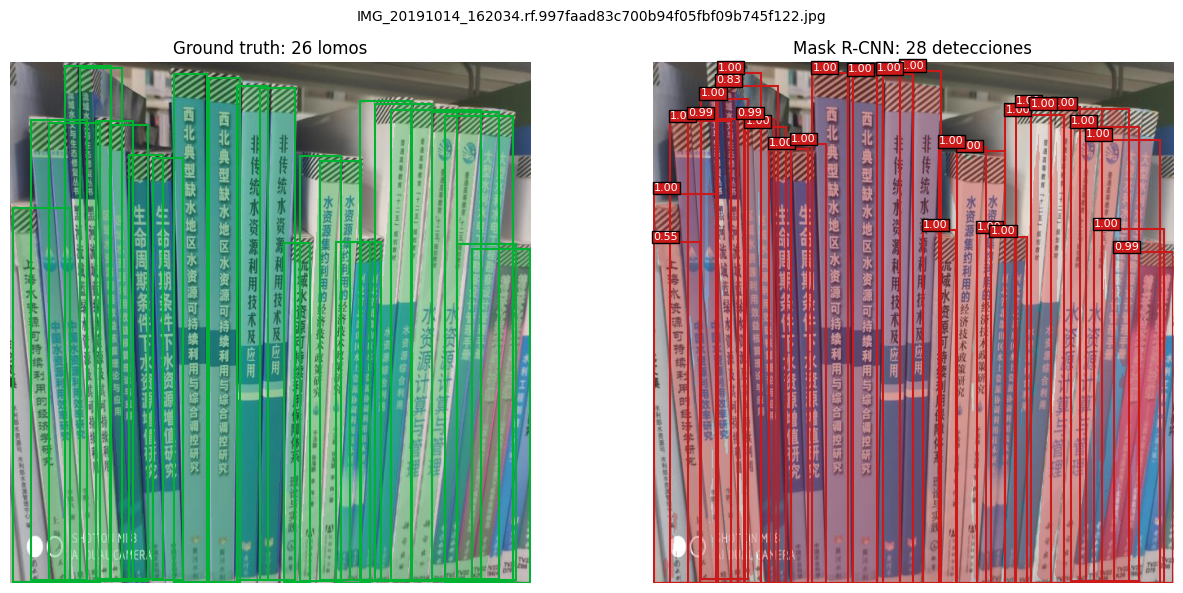

Guardadas 13 figuras en /content/results/figures/mask_rcnn


In [19]:
def dibujar_instancias(eje, imagen, mascaras, cajas, color, scores=None):
    eje.imshow(imagen)
    alto, ancho = imagen.shape[:2]

    capa = np.zeros((alto, ancho, 4), dtype=float)
    for mascara in mascaras:
        capa[np.asarray(mascara, dtype=bool)] = (*color, 0.30)
    eje.imshow(capa)

    for i, caja in enumerate(cajas):
        x1, y1, x2, y2 = [float(v) for v in caja]
        eje.add_patch(Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor=color,
            linewidth=1.5,
        ))
        if scores is not None:
            eje.text(
                x1,
                max(0, y1 - 3),
                f"{float(scores[i]):.2f}",
                color="white",
                fontsize=8,
                bbox={"facecolor": color, "pad": 1},
            )

    eje.axis("off")


rng = random.Random(42)
aleatorios = rng.sample(
    list(range(len(valid_ds))),
    k=min(4, len(valid_ds)),
)
mas_fn = detalle_validacion.nlargest(3, "fn_mascara")["indice"].tolist()
mas_fp = detalle_validacion.nlargest(3, "fp_mascara")["indice"].tolist()
densos = detalle_validacion.query("densa").head(2)["indice"].tolist()
inclinados = detalle_validacion.query("inclinada").head(2)["indice"].tolist()

# Mantiene el orden y elimina imágenes repetidas.
indices_figuras = list(dict.fromkeys(
    aleatorios + mas_fn + mas_fp + densos + inclinados
))

for numero, indice in enumerate(indices_figuras, start=1):
    imagen, gt = valid_ds[indice]

    with torch.inference_mode():
        salida = modelo([imagen.to(dispositivo)])[0]

    conservar = (
        (salida["scores"] >= SCORE_EVAL)
        & (salida["labels"] == 1)
    )

    imagen_np = imagen.permute(1, 2, 0).numpy()
    mascaras_pred = (
        salida["masks"][conservar, 0] >= UMBRAL_MASCARA
    ).cpu().numpy()

    figura, ejes = plt.subplots(1, 2, figsize=(13, 6))
    dibujar_instancias(
        ejes[0],
        imagen_np,
        gt["masks"].numpy(),
        gt["boxes"].numpy(),
        color=(0.0, 0.7, 0.2),
    )
    dibujar_instancias(
        ejes[1],
        imagen_np,
        mascaras_pred,
        salida["boxes"][conservar].cpu().numpy(),
        color=(0.8, 0.1, 0.1),
        scores=salida["scores"][conservar].cpu().numpy(),
    )

    ejes[0].set_title(f"Ground truth: {len(gt['labels'])} lomos")
    ejes[1].set_title(f"Mask R-CNN: {int(conservar.sum())} detecciones")
    figura.suptitle(valid_ds.imagenes[indice].name, fontsize=10)
    figura.tight_layout()

    figura.savefig(
        DIRECTORIO_FIGURAS / f"gt_vs_pred_{indice:04d}.png",
        dpi=150,
    )
    if numero <= 2:
        plt.show()
    else:
        plt.close(figura)

print(f"Guardadas {len(indices_figuras)} figuras en {DIRECTORIO_FIGURAS}")

## Análisis cualitativo

En los ejemplos visualizados, Mask R-CNN detecta la mayoría de los lomos y produce máscaras que, en general, siguen su orientación y separación.

También se observan errores de sobresegmentación y detecciones duplicadas. En el primer ejemplo mostrado existen 25 lomos anotados y el modelo genera 33 detecciones, incluyendo una detección extensa sobre la zona inferior de la estantería. En el segundo ejemplo, la diferencia es menor: 26 lomos reales frente a 28 detecciones.

Estos errores son importantes para la etapa de OCR. Un falso positivo puede generar un recorte sin texto útil, mientras que una detección duplicada puede hacer que el mismo título sea reconocido más de una vez. Por ello, además de la segmentación, el flujo completo debería incorporar filtrado por confianza, eliminación de duplicados y validación de los recortes antes de ejecutar OCR.

In [20]:
resumen_test, _ = evaluar_particion(
    test_ds,
    incluir_subconjuntos=False,
)

latencia_test = medir_latencia(test_ds)
resumen_test["global"]["latencia_ms"] = latencia_test
resumen_test["global"]["fps"] = 1000 / latencia_test

comparacion = pd.DataFrame([
    {"particion": "validación", **resumen_validacion["global"]},
    {"particion": "test", **resumen_test["global"]},
])

display(comparacion.round(4))

comparacion.to_csv(
    DIRECTORIO_TABLAS / "mask_rcnn_val_vs_test.csv",
    index=False,
)

(DIRECTORIO_TABLAS / "mask_rcnn_resumen_test.json").write_text(
    json.dumps({
        "checkpoint": str(RUTA_MEJOR),
        "epoca": int(checkpoint["epoca"]),
        "score_eval": SCORE_EVAL,
        "iou_eval": IOU_EVAL,
        "resultados": resumen_test["global"],
    }, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

Evaluación:   0%|          | 0/120 [00:00<?, ?it/s]

Latencia:   0%|          | 0/55 [00:00<?, ?it/s]

,particion,imagenes,gt,mask_map50,mask_map50_95,mask_precision,mask_recall,box_map50,box_map50_95,box_precision,box_recall,latencia_ms,fps
0,validación,271,4622,0.7846,0.5074,0.7846,0.8336,0.9089,0.7282,0.8644,0.9184,117.3399,8.5223
1,test,120,1747,0.7763,0.5175,0.7567,0.8386,0.9475,0.7501,0.8559,0.9485,112.7578,8.8686


579

## Evaluación final en test

| Métrica | Validación | Test |
| :--- | ---: | ---: |
| Imágenes | 271 | 120 |
| Lomos reales | 4.622 | 1.747 |
| mAP@0.5 de máscara | 0,7846 | 0,7763 |
| mAP@0.5:0.95 de máscara | 0,5074 | 0,5175 |
| Precisión de máscara | 0,7846 | 0,7567 |
| Recall de máscara | 0,8336 | 0,8386 |
| mAP@0.5 de caja | 0,9089 | 0,9475 |
| mAP@0.5:0.95 de caja | 0,7282 | 0,7501 |
| Latencia | 117,34 ms | 112,76 ms |
| Rendimiento | 8,52 FPS | 8,87 FPS |

El mAP@0.5 de máscara disminuyó solamente 0,0083 entre validación y test, mientras que el mAP@0.5:0.95 aumentó 0,0101. El recall también permaneció estable.

Estos resultados muestran un comportamiento consistente entre ambas particiones a nivel de archivo. Sin embargo, deben interpretarse junto con la posible fuga de información detectada entre fotografías provenientes de una misma fuente.